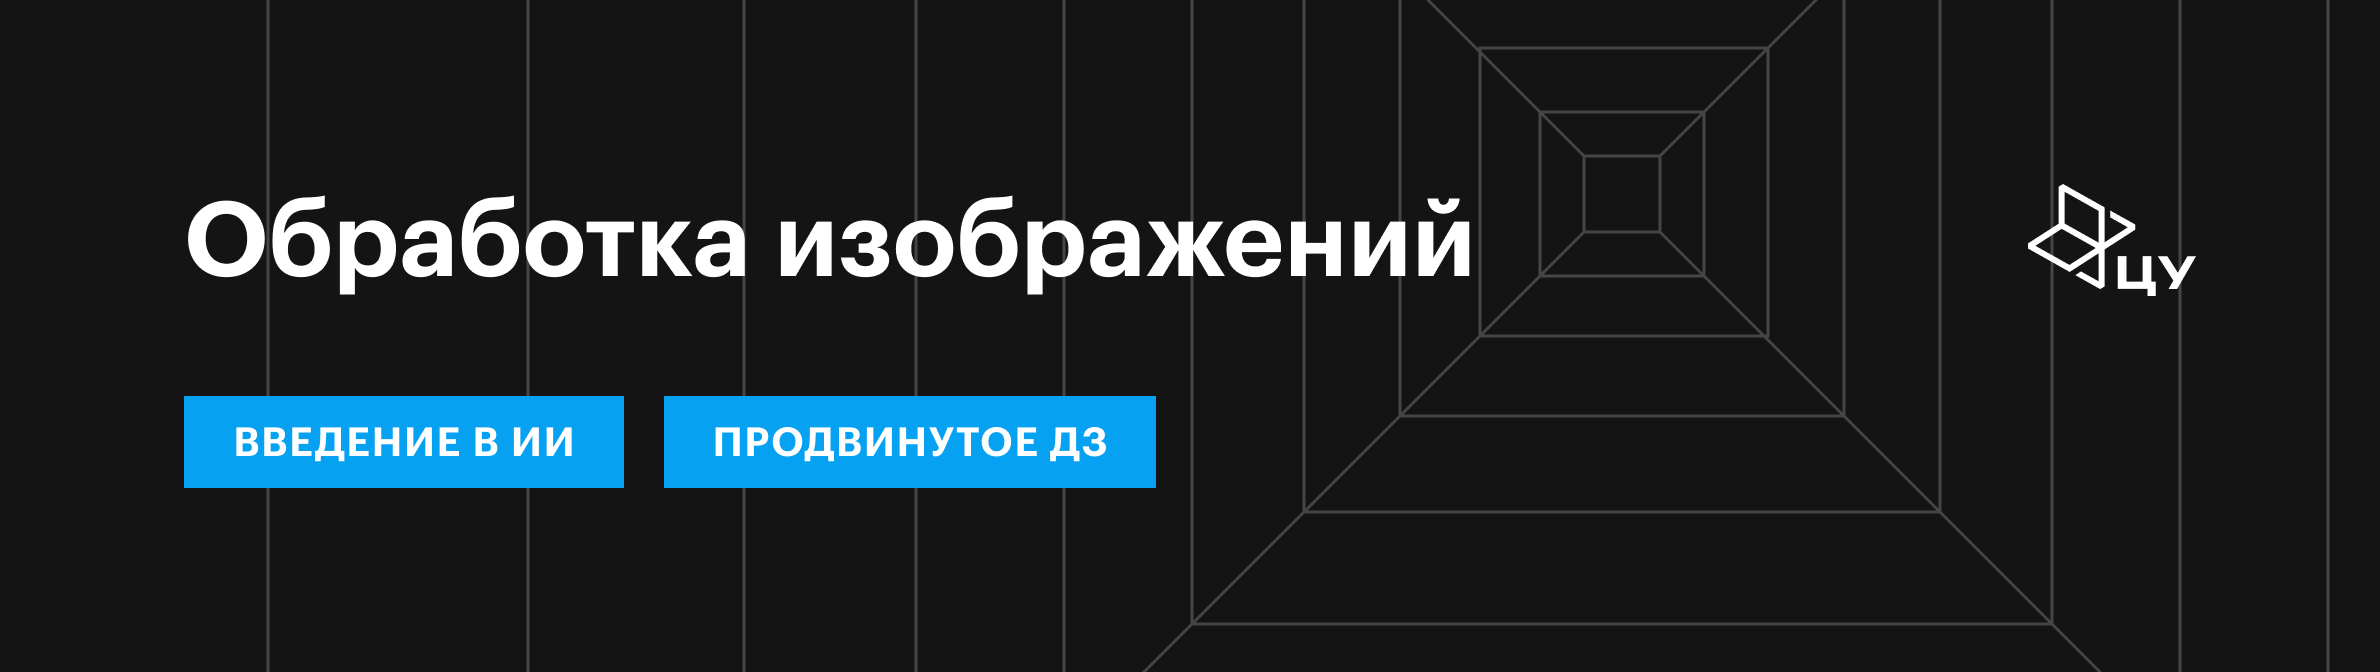

# Домашнее задание по теме «Обработка изображений»



В этом задании ты научишься менять размер изображения с помощью интерполяции, познакомишься с новым методом бинаризации, а также улучшишь классификатор изображений из семинара.

> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием `# Напиши код здесь`.
>
> 4. После каждого задания старайся коротко интерпретировать результат, а не только получать числа.
>
> 5. Все ячейки должны запускаться последовательно сверху-вниз. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.

## Вспомогательные функции и подготовка данных





Ты поработаешь с библиотеками PIL для работы с изображениями, np, pandas для работы с данными и  matplotlib для их визуализации. Для обучения и тестирования моделей воспользуешься sklearn.

Тебе также доступны вспомогательные функции:

- `show_images` — для визуализации нескольких изображений,

- `plot_hist` — для визуализации гистограммы изображений,

- `psnr` — для рассчёта метрики PSNR.

In [1]:
# @title Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["axes.grid"] = False

RNG = np.random.default_rng(42)

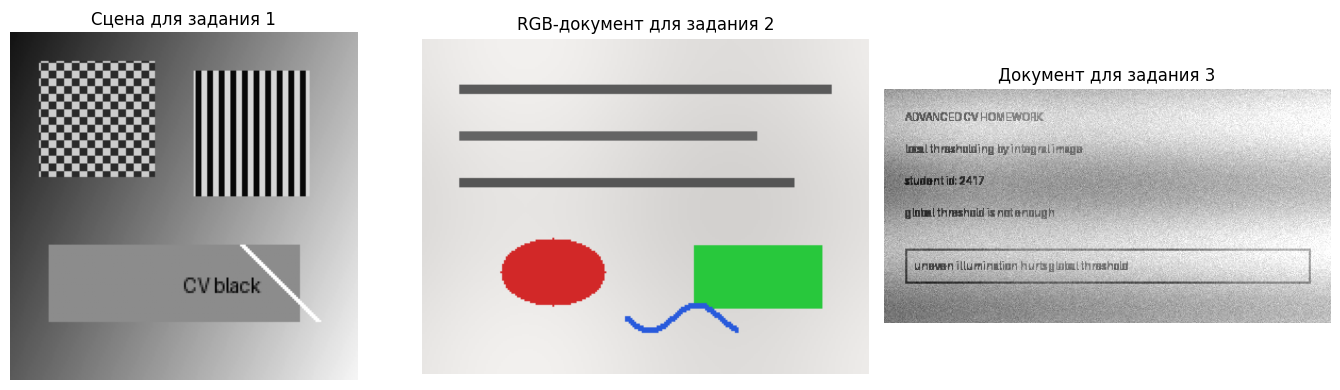

In [2]:
#@title Вспомогательные функции
def show_images(images, titles=None, cmaps=None, ncols=None, figsize=None, vmin=None, vmax=None):
    n = len(images)
    if titles is None:
        titles = [""] * n
    if cmaps is None:
        cmaps = [None] * n
    if ncols is None:
        ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))

    if figsize is None:
        figsize = (4 * ncols, 3.5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        arr = np.asarray(image)
        if cmap is None and arr.ndim == 2:
            cmap = "gray"
        ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_hist(ax, image, title, bins=256, span=(0, 255), color="black"):
    ax.hist(np.asarray(image).ravel(), bins=bins, range=span, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Яркость")
    ax.set_ylabel("Частота")


def psnr(image_a, image_b, peak=255.0):
    image_a = np.asarray(image_a, dtype=float)
    image_b = np.asarray(image_b, dtype=float)
    mse = np.mean((image_a - image_b) ** 2)
    if mse == 0:
        return np.inf
    return 10 * np.log10((peak ** 2) / mse)


def segmentation_report(y_true, y_pred):
    y_true = np.asarray(y_true).ravel().astype(np.uint8)
    y_pred = np.asarray(y_pred).ravel().astype(np.uint8)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pixel_accuracy": float((y_true == y_pred).mean()),
    }


def make_resampling_scene(h=180, w=180):
    y, x = np.mgrid[0:h, 0:w]
    base = 40 + 0.75 * x + 0.35 * y
    img = np.clip(base, 0, 255).astype(np.uint8)

    # Шахматный узор высокой частоты
    tile = (((x // 4) + (y // 4)) % 2) * 140
    img[15:75, 15:75] = np.clip(60 + tile[15:75, 15:75], 0, 255)

    # Узкие полосы
    stripes = ((x // 3) % 2) * 180
    img[20:85, 95:155] = np.clip(30 + stripes[20:85, 95:155], 0, 255)

    # Тонкие линии
    img[110:150, 20:150] = 145
    for shift in range(-1, 2):
        rr = np.arange(110, 150)
        cc = rr + 10 + shift
        valid = (cc >= 0) & (cc < w)
        img[rr[valid], cc[valid]] = 245

    # Текст для проверки мелких деталей
    canvas = Image.fromarray(img)
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default()
    draw.text((90, 125), "CV black", fill=20, font=font)
    return np.array(canvas, dtype=np.uint8)


def make_color_document(h=180, w=240):
    img = np.full((h, w, 3), 235, dtype=np.uint8)
    y, x = np.mgrid[0:h, 0:w]

    paper = 225 + 10 * np.sin(x / 35) + 6 * np.cos(y / 29)
    img[..., 0] = np.clip(paper + 2, 0, 255)
    img[..., 1] = np.clip(paper, 0, 255)
    img[..., 2] = np.clip(paper - 2, 0, 255)

    # Текст
    img[25:30, 20:220] = 90
    img[50:55, 20:180] = 100
    img[75:80, 20:200] = 85

    # Красная печать — целевой объект
    red_mask = ((x - 70) ** 2 / (28 ** 2) + (y - 125) ** 2 / (18 ** 2) <= 1)
    img[red_mask] = [210, 40, 40]

    # Зелёная плашка и синяя подпись — отвлекающие объекты
    green_mask = (x > 145) & (x < 215) & (y > 110) & (y < 145)
    img[green_mask] = [40, 200, 60]

    for k in range(110, 170):
        yy = int(150 + 7 * np.sin((k - 110) / 8))
        img[max(0, yy - 1):min(h, yy + 2), max(0, k - 1):min(w, k + 1)] = [40, 90, 220]

    return img, red_mask.astype(np.uint8)


def make_text_mask(width=420, height=220, margin=20):
    canvas = Image.new("L", (width, height), color=0)
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default()

    lines = [
        "ADVANCED CV HOMEWORK",
        "local thresholding by integral image",
        "student id: 2417",
        "global threshold is not enough",
    ]

    y = margin
    for line in lines:
        draw.text((margin, y), line, fill=255, font=font)
        y += 30

    draw.rectangle([margin, 150, width - margin, 182], outline=255, width=2)
    draw.text((margin + 8, 160), "uneven illumination hurts global threshold", fill=255, font=font)

    return (np.array(canvas) > 0).astype(np.uint8)


def make_document(mask, seed=0):
    rng = np.random.default_rng(seed)
    h, w = mask.shape
    y, x = np.mgrid[0:h, 0:w]

    background = (
        175
        + 55 * (x / (w - 1))
        + 25 * np.sin(y / 19)
        + 18 * np.exp(-((x - 85) ** 2 + (y - 60) ** 2) / (2 * 50 ** 2))
    )
    text = background - (70 + 15 * np.sin(x / 33))

    image = np.where(mask == 1, text, background)
    image += rng.normal(0, 8, size=(h, w))

    return np.clip(image, 0, 255).astype(np.uint8)


scene = make_resampling_scene()
doc_rgb, red_mask = make_color_document()
gt_text = make_text_mask()
hard_doc = make_document(gt_text, seed=3)

show_images(
    [scene, doc_rgb, hard_doc],
    titles=["Сцена для задания 1", "RGB-документ для задания 2", "Документ для задания 3"],
    ncols=3,
    figsize=(14, 4),
)

## Задание 1. Ручное изменение размера изображения с помощью билинейной интерполяции [3 балла]

Цифровое изображение — это двумерная функция яркости, заданная на двумерной дискретной сетке. При изменении размера изображения эта сетка меняется: новые пиксели обычно не совпадают с исходными. Поэтому значения в новых точках нужно восстанавливать с помощью интерполяции.

Реализуй вручную **билинейную интерполяцию** и используй её для масштабирования изображения. Для этого нужно следующее.

1. [0.8 балла] Реализовать функцию `bilinear_sample(image, x, y)`, которая возвращает значение изображения в нецелой точке $(x,\,y)$.
2. [0.8 балла] Реализовать функцию `resize_bilinear(image, new_h, new_w)`, которая изменяет размер изображения с помощью билинейной интерполяции.
3. [0.5 балла] Провести эксперимент на изображении *scene*:
   - увеличить изображение в 2 раза,
   - уменьшить его обратно до исходного размера,
   - сравнить исходное изображение и восстановленное после цепочки `upscale → downscale`.
4. [0.4 балла] Посчитать метрики:
   - `MAE`,
   - `PSNR`.

Кратко ответь на вопросы.
[0.5 балла]
- Почему при масштабировании возникает задача интерполяции?
- Почему после последовательности «*увеличение → уменьшение*» изображение уже не совпадает с исходным?
- Какие детали страдают сильнее всего: гладкие области или высокочастотные структуры?

**Ограничения**

- Не используй `cv2.resize`, `scipy.ndimage`, `skimage.transform` и другие готовые функции интерполяции.
- Ключевая часть должна быть реализована вручную на `numpy`.

MAE:  4.2678
PSNR: 28.3414 dB


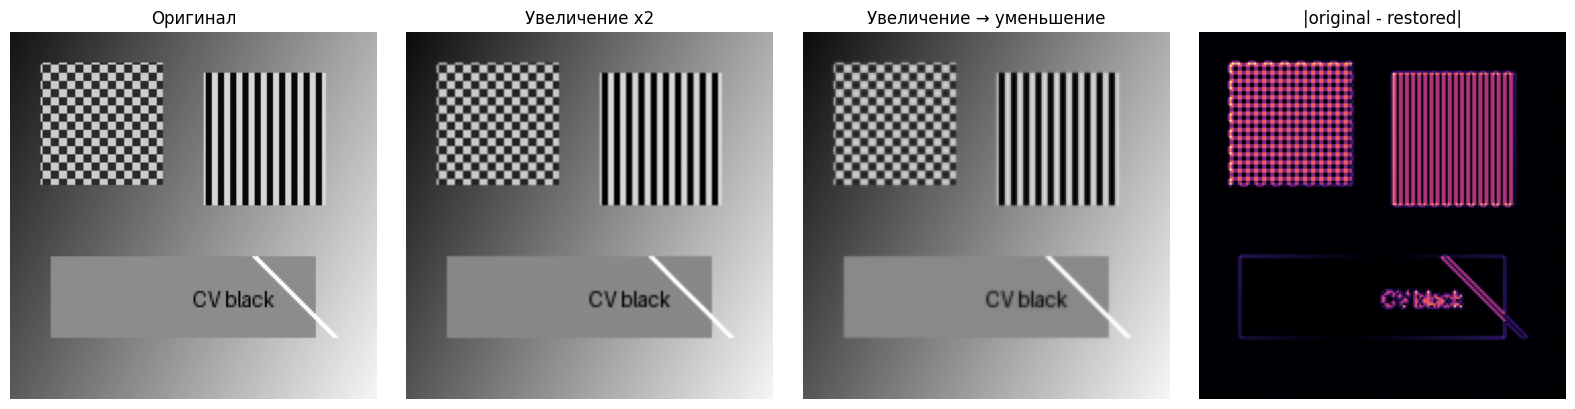

In [3]:
def bilinear_sample(image, x, y):
    """
    Возвращает значение изображения в точке (x, y)
    с помощью билинейной интерполяции.

    Параметры:
        image: np.ndarray формы (H, W)
        x: float — координата по ширине
        y: float — координата по высоте

    Возвращает:
        float — интерполированное значение
    """
    h, w = image.shape

    x = np.clip(x, 0, w - 1)
    y = np.clip(y, 0, h - 1)

    x1 = int(np.floor(x))
    x2 = min(x1 + 1, w - 1)
    y1 = int(np.floor(y))
    y2 = min(y1 + 1, h - 1)

    dx = x - x1
    dy = y - y1

    return (
        image[y1, x1] * (1 - dx) * (1 - dy) +
        image[y1, x2] * dx * (1 - dy) +
        image[y2, x1] * (1 - dx) * dy +
        image[y2, x2] * dx * dy
    )


def resize_bilinear(image, new_h, new_w):
    """
    Масштабирует изображение до размера (new_h, new_w)
    с помощью билинейной интерполяции.

    Параметры:
        image: np.ndarray формы (H, W)
        new_h, new_w: int

    Возвращает:
        np.ndarray формы (new_h, new_w)
    """
    h, w = image.shape
    result = np.zeros((new_h, new_w), dtype=float)
    for i in range(new_h):
        for j in range(new_w):
            x = (j + 0.5) * w / new_w - 0.5
            y = (i + 0.5) * h / new_h - 0.5
            result[i, j] = bilinear_sample(image, x, y)

    return result


# ===== Эксперимент =====
image = scene.copy()

upscaled = resize_bilinear(image, image.shape[0] * 2, image.shape[1] * 2)
restored = resize_bilinear(upscaled, image.shape[0], image.shape[1])

mae = np.mean(np.abs(image.astype(float) - restored.astype(float)))
cur_psnr = psnr(image, restored)

print(f"MAE:  {mae:.4f}")
print(f"PSNR: {cur_psnr:.4f} dB")

diff = np.abs(image.astype(float) - restored.astype(float))

show_images(
    [image, upscaled, restored, diff],
    titles=[
        "Оригинал",
        "Увеличение x2",
        "Увеличение → уменьшение",
        "|original - restored|",
    ],
    cmaps=["gray", "gray", "gray", "magma"],
    ncols=4,
    figsize=(16, 4),
)

In [4]:
img = np.array([[1, 2], [3, 4]])

bilinear_sample(img, 0.9, 0.1)
resize_bilinear(img, 2, 2)

array([[1., 2.],
       [3., 4.]])

Напиши ответы на вопросы здесь

Ниже приведены проверки, благодаря которым ты сможешь понять, правильно ли работает твой код:

В этих тестах зафиксированы следующие соглашения:

1. В `bilinear_sample(image, x, y)` на границе изображения используются допустимые соседи внутри массива:
   - `x0 = floor(x)`, `x1 = min(x0 + 1, W - 1)`
   - `y0 = floor(y)`, `y1 = min(y0 + 1, H - 1)`

2. В `resize_bilinear(image, new_h, new_w)` координаты новой сетки переводятся в старую через
   - `xs = np.linspace(0, W - 1, new_w)`
   - `ys = np.linspace(0, H - 1, new_h)`

Проверки ниже тестируют:
- значения в целых точках;
- значение в нецелой точке;
- граничный случай;
- корректность `resize_bilinear` на маленьком искусственном примере, где ожидаемый ответ можно выписать вручную.

Если все `assert` проходят, значит базовая логика билинейной интерполяции реализована корректно.

In [5]:
# @title Проверки
toy = np.array([
    [0.0, 10.0],
    [20.0, 30.0],
], dtype=np.float64)

# 1) Проверка целых точек: в узлах сетки должно возвращаться исходное значение пикселя
assert np.isclose(bilinear_sample(toy, 0.0, 0.0), 0.0), \
    "Ошибка: bilinear_sample(toy, 0.0, 0.0) должно быть равно 0.0"

assert np.isclose(bilinear_sample(toy, 1.0, 0.0), 10.0), \
    "Ошибка: bilinear_sample(toy, 1.0, 0.0) должно быть равно 10.0"

assert np.isclose(bilinear_sample(toy, 0.0, 1.0), 20.0), \
    "Ошибка: bilinear_sample(toy, 0.0, 1.0) должно быть равно 20.0"

assert np.isclose(bilinear_sample(toy, 1.0, 1.0), 30.0), \
    "Ошибка: bilinear_sample(toy, 1.0, 1.0) должно быть равно 30.0"

# 2) Проверка нецелой точки внутри изображения
assert np.isclose(bilinear_sample(toy, 0.25, 0.75), 17.5), \
    "Ошибка: bilinear_sample(toy, 0.25, 0.75) должно быть равно 17.5"

# 3) Граничный случай: x находится на правой границе
assert np.isclose(bilinear_sample(toy, 1.0, 0.4), 18.0), \
    "Ошибка: bilinear_sample(toy, 1.0, 0.4) должно быть равно 18.0"

# 4) Проверка resize_bilinear на маленьком массиве 2x2 -> 3x3
expected_resized = np.array([
    [0.0,  5.0, 10.0],
    [10.0, 15.0, 20.0],
    [20.0, 25.0, 30.0],
], dtype=np.float64)

actual_resized = resize_bilinear(toy, 3, 3)

assert actual_resized.shape == (3, 3), \
    f"Ошибка: resize_bilinear(toy, 3, 3) должно вернуть массив формы (3, 3), а получено {actual_resized.shape}"

assert np.allclose(actual_resized, expected_resized, atol=1e-8), (
    "Ошибка: resize_bilinear(toy, 3, 3) даёт неверный результат.\n"
    f"Ожидалось:\n{expected_resized}\n"
    f"Получено:\n{np.asarray(actual_resized, dtype=float)}"
)

print("bilinear_sample и resize_bilinear работают корректно на детерминированных тестах.")

bilinear_sample и resize_bilinear работают корректно на детерминированных тестах.


## Задание 2. Локальная бинаризация через интегральное изображение [3 балла]

В продвинутом семинаре недели 9 обсуждались глобальные пороги. Это полезный базовый инструмент, но как только освещение начинает заметно меняться по изображению, один глобальный порог становится ненадёжным.

В этом задании тебе нужно перейти от одного глобального порога к локальным статистикам, которые считаются в окрестности каждого пикселя.

Чтобы реализовать такой метод, нужно быстро находить локальное среднее в окне вокруг пикселя. Для этого используют интегральное изображение: оно позволяет вычислять сумму по прямоугольной области за
$O(1)$.


Интегральное изображение $L$ вычисляется по исходному $I$ следующим образом:

$$
L(x,\,y) = \sum_{i=0}^{x}\sum_{j=0}^{y} I(i,\,j).
$$

Сумма по прямоугольнику через интегральное изображение вычисляется так:

$$
S = L(x_2,\,y_2) - L(x_2,\,y_1) - L(x_1,\,y_2) + L(x_1,\,y_1).
$$


Зная сумму по окну, можно получить локальное среднее и задать адаптивный порог. Для тёмного текста на светлом фоне используй правило:

$$
I(x,\,y) \le \mu_{local}(x,\,y) - c,
$$

где $c$ — небольшой сдвиг.

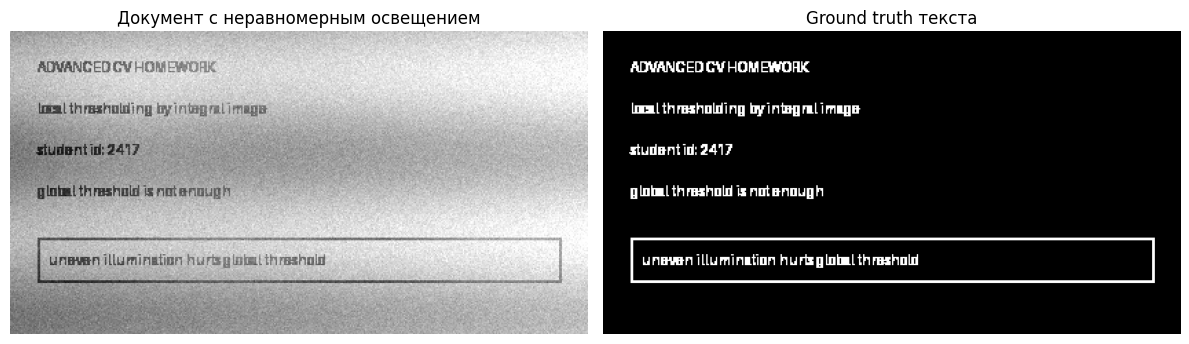

In [6]:
show_images(
    [hard_doc, gt_text],
    titles=["Документ с неравномерным освещением", "Ground truth текста"],
    ncols=2,
    figsize=(12, 4),
)



<!-- Реализуй:
- `integral_image(image)`
- `rect_sum(ii, top, left, bottom, right)`
- `adaptive_mean_threshold(image, window=15, offset=15)`

Функция `otsu_threshold(image)` дана как baseline, её писать не нужно. -->
Теперь проверь этот подход.

1. [1.2 баллa] Реализуй функции:
   - `integral_image(image)` [0.4 баллa],
   - `rect_sum(ii, top, left, bottom, right)` [0.4 баллa],
   - `adaptive_mean_threshold(image, window=15, offset=15)` [0.4 баллa].

2. [1 балл] Сравни локальный метод с глобальным порогом Оцу на документе с сильной неравномерной засветкой.

3. [0.8 баллa] Оцени качество по метрикам:
   - `precision`,
   - `recall`,
   - `F1`,
   - `pixel_accuracy`.

In [7]:
def integral_image(image):
    ii = np.cumsum(image, axis=0)
    ii = np.cumsum(ii, axis=1)
    return ii

def rect_sum(ii, top, left, bottom, right):
    s = ii[bottom, right]
    if top > 0:
        s -= ii[top - 1, right]
    if left > 0:
        s -= ii[bottom, left - 1]
    if top > 0 and left > 0:
        s += ii[top - 1, left - 1]
    return s

def adaptive_mean_threshold(image, window=15, offset=15):
    h, w = image.shape
    r = window // 2

    ii = integral_image(image.astype(np.float64))
    result = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            top = max(0, i - r)
            left = max(0, j - r)
            bottom = min(h - 1, i + r)
            right = min(w - 1, j + r)

            area = (bottom - top + 1) * (right - left + 1)
            local_mean = rect_sum(ii, top, left, bottom, right) / area

            result[i, j] = 255 if image[i, j] > local_mean - offset else 0

    return result

def otsu_threshold(image):
    hist = np.bincount(image.ravel(), minlength=256).astype(float)
    p = hist / hist.sum()
    omega = np.cumsum(p)
    mu = np.cumsum(p * np.arange(256))
    mu_total = mu[-1]
    sigma_between = (mu_total * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)
    return int(np.argmax(sigma_between))

## Задание 3. MLP на CIFAR-10: усложняем baseline [4 балла]

На семинаре мы уже обучали **логистическую регрессию** на `flatten`-представлении изображений.  
Для датасета CIFAR-10 рассматривалась бинарная задача: отличить кошек от собак.

Теперь сделай следующий шаг: вместо линейной модели обучи **MLP** и перейди к **4-классовой** классификации на CIFAR-10.

Чтобы задача оставалась разумной по времени и при этом была не слишком простой, возьмём 4 класса транспорта:

- `airplane`,
- `automobile`,
- `ship`,
- `truck`.

Порядок действий следующий.

1. [0.2 баллa] Скачай CIFAR-10.
2. [0.3 баллa] Оставь только 4 указанных класса.
3. [0.2 баллa] Разверни каждое изображение $32 \times 32 \times 3$ в вектор признаков.
4. [0.3 баллa] Раздели train на подвыборки train и val.
5. [1.5 баллa] Обучи MLP для многоклассовой классификации.
6. [0.5 баллa] Посчитай качество на тесте:
   - `accuracy`,
   - `macro-F1`.
7. [1 балл] Сделай короткий вывод:
   - почему MLP оказался сильнее логистической регрессии;
   - почему даже такой подход всё равно остаётся ограниченным для изображений.

>**Примечание.** Ты по-прежнему работаешь с `flatten`-представлением.  
Это значит, что модель всё ещё не учитывает пространственную структуру изображения так естественно, как это делают специальные архитектуры для CV. Но по сравнению с линейной моделью MLP уже умеет строить *нелинейные разделяющие поверхности*, поэтому качество должно стать заметно лучше.

In [2]:
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [7]:
def set_seed(seed=42):
    torch.manual_seed(seed)

def show_images(images, titles=None, cmaps=None, ncols=4, figsize=(10, 8), vmin=None, vmax=None):
    n = len(images)
    if titles is None:
        titles = [""] * n
    if cmaps is None:
        cmaps = [None] * n
    if ncols is None:
        ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))

    if figsize is None:
        figsize = (4 * ncols, 3.5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        arr = np.asarray(image)
        if cmap is None and arr.ndim == 2:
            cmap = "gray"
        ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def load_cifar_subset(root="/content/data", selected_classes=(0, 1, 8, 9)):
    train = CIFAR10(root=root, train=True, download=True)
    test = CIFAR10(root=root, train=False, download=True)

    X_train = train.data
    y_train = np.array(train.targets)
    X_test = test.data
    y_test = np.array(test.targets)

    print(type(y_train))

    train_mask = np.isin(y_train, selected_classes)
    test_mask = np.isin(y_test, selected_classes)

    X_train = X_train[train_mask]
    y_train = y_train[train_mask]
    X_test = X_test[test_mask]
    y_test = y_test[test_mask]

    remnant = {cls: i for i, cls in enumerate(selected_classes)}
    y_train = np.array([remnant[y] for y in y_train])
    y_test = np.array([remnant[y] for y in y_test])

    class_names = [train.classes[cls] for cls in selected_classes]

    return X_train, y_train, X_test, y_test, class_names

def flatten_images(images):
    return images.reshape((images.shape[0], -1))

def standardize_features(x_train, x_val, x_test):
    m = x_train.mean(axis=0)
    std = x_train.std(axis=0)

    x_train = (x_train - m) / std
    x_val = (x_val - m) / std
    x_test = (x_test - m) / std

    return x_train, x_val, x_test

class MLPNet(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def make_loaders(x_train, y_train, x_val, y_val, x_test, y_test, batch_size=512):
    train_ds = TensorDataset(
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    val_ds = TensorDataset(
        torch.tensor(x_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )
    test_ds = TensorDataset(
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=batch_size)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    return train_loader, val_loader, test_loader

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return acc, macro_f1

def train_model(model, train_loader, val_loader, device, epochs=25, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

    h = {
        "train_loss": [],
        "val_acc": [],
        "val_macro_f1": []
    }

    for epoch in range(epochs):

        train_loss = 0
        model.train()
        for xb, yb in train_loader:
          xb = xb.to(device)
          yb = yb.to(device)

          logits = model(xb)
          loss = criterion(logits, yb)

          train_loss += loss.item()

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
        acc, macro_f1 = evaluate_model(model, val_loader, device)
        scheduler.step(macro_f1)
        print(f"Epoch: {epoch} | Train Loss: {train_loss / len(train_loader)} | Accuracy: {acc} | f1: {macro_f1}")


        h["train_loss"].append(train_loss / len(train_loader))
        h["val_acc"].append(acc)
        h["val_macro_f1"].append(macro_f1)

    return model, h

# 1. Зафиксируй seed
set_seed()


# 2. Загрузи CIFAR-10 и оставь 4 класса: airplane, automobile, ship, truck
X_train, y_train, X_test, y_test, class_names = load_cifar_subset()

# 3. Покажи несколько примеров изображений

# sample_idx = []
# for cls_id in range(len(class_names)):
#     idx = np.where(y_train == cls_id)[0][:3]
#     sample_idx.extend(idx.tolist())

# sample_images = [X_train[i] for i in sample_idx]
# sample_titles = [class_names[y_train[i]] for i in sample_idx]
# show_images(sample_images, titles=sample_titles)

# 4. Разверни изображения в векторы
X_train = flatten_images(X_train)
X_test = flatten_images(X_test)

# 5. Раздели train на train/val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 6. Нормализуй признаки
X_train, X_val, X_test = standardize_features(X_train, X_val, X_test)

# 7. Обучи MLP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, test_loader = make_loaders(X_train, y_train, X_val, y_val, X_test, y_test)
model = MLPNet(X_train.shape[1], len(class_names)).to(device)
model, h = train_model(model, train_loader, val_loader, device)

# 8. Посчитай accuracy и macro-F1 на test
test_acc, test_f1 = evaluate_model(model, test_loader, device)

# 9. Выведи итоговую таблицу результатов
results_df = pd.DataFrame(
    [{
        "model": "MLP",
        "classes": ", ".join(class_names),
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1
    }]
)

print("Final results:")
display(results_df)

# Напиши код здесь

<class 'numpy.ndarray'>
Epoch: 0 | Train Loss: 1.0718173161149025 | Accuracy: 0.60675 | f1: 0.6026327271086755
Epoch: 1 | Train Loss: 0.8798044826835394 | Accuracy: 0.63125 | f1: 0.6273102373618644
Epoch: 2 | Train Loss: 0.7865520939230919 | Accuracy: 0.658 | f1: 0.6566127134666524
Epoch: 3 | Train Loss: 0.6959068104624748 | Accuracy: 0.676 | f1: 0.6748007522047874
Epoch: 4 | Train Loss: 0.6012536603957415 | Accuracy: 0.68725 | f1: 0.6871218029338967
Epoch: 5 | Train Loss: 0.5376570150256157 | Accuracy: 0.6885 | f1: 0.68790564687077
Epoch: 6 | Train Loss: 0.46522269723936915 | Accuracy: 0.688 | f1: 0.6874017530305937
Epoch: 7 | Train Loss: 0.3996890189591795 | Accuracy: 0.698 | f1: 0.6974345085730622
Epoch: 8 | Train Loss: 0.3647612491622567 | Accuracy: 0.6935 | f1: 0.6929832886485923
Epoch: 9 | Train Loss: 0.3215806402731687 | Accuracy: 0.68875 | f1: 0.6882987831375703
Epoch: 10 | Train Loss: 0.2796891264151782 | Accuracy: 0.71025 | f1: 0.7103904520825028
Epoch: 11 | Train Loss: 0.244

{'train_loss': [1.0718173161149025,
  0.8798044826835394,
  0.7865520939230919,
  0.6959068104624748,
  0.6012536603957415,
  0.5376570150256157,
  0.46522269723936915,
  0.3996890189591795,
  0.3647612491622567,
  0.3215806402731687,
  0.2796891264151782,
  0.24487610929645598,
  0.2171764278318733,
  0.19239953067153692,
  0.17378451419062912,
  0.15902346500661224,
  0.14471782854525372,
  0.13719617581227794,
  0.13159740256378427,
  0.12572329107206315,
  0.12247812395798974,
  0.11944134754594415,
  0.11590672036982141,
  0.11398900375934318,
  0.11268131391261704],
 'val_acc': [0.60675,
  0.63125,
  0.658,
  0.676,
  0.68725,
  0.6885,
  0.688,
  0.698,
  0.6935,
  0.68875,
  0.71025,
  0.71075,
  0.70975,
  0.70475,
  0.70775,
  0.70825,
  0.711,
  0.71025,
  0.7105,
  0.712,
  0.713,
  0.71225,
  0.712,
  0.71075,
  0.711],
 'val_macro_f1': [0.6026327271086755,
  0.6273102373618644,
  0.6566127134666524,
  0.6748007522047874,
  0.6871218029338967,
  0.68790564687077,
  0.68740


Final results:


,model,classes,test_accuracy,test_macro_f1
0,MLP,"airplane, automobile, ship, truck",0.7095,0.7094
